In [10]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [11]:
import torch
print(torch.cuda.is_available())

True


In [9]:
import glob
import random
import cv2
import matplotlib.pyplot as plt
import yaml
import os

In [ ]:
!pip install ultralytics

In [13]:
from ultralytics import YOLO

In [12]:
model = YOLO('yolov8m.pt')
results = model.train(
    data=r'/content/2022170413/blood_cell_config.yaml',
    epochs=50,
    imgsz=640,
    project='blood_cell_project',
    name='yolov8m_run',
    plots=True
)

Ultralytics 8.3.234 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/2022170413/blood_cell_config.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8m_run, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0

In [14]:
metrics = model.val()
print("\n--- Model B Results ---")
print(f"mAP@50: {metrics.box.map50:.4f}")
print(f"Recall: {metrics.box.mr:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"mAP@50-95: {metrics.box.map:.4f}")

Ultralytics 8.3.234 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 763.9±201.1 MB/s, size: 20.5 KB)
val: Scanning /content/2022170413/yolo_dataset/labels/test.cache... 73 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 73/73 82.8Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.6it/s 3.2s
                   all         73       1038       0.85      0.892      0.923      0.639
                   WBC         72         74      0.956          1      0.994      0.807
                   RBC         70        864      0.765      0.803      0.862      0.603
             Platelets         49        100      0.829      0.871      0.912      0.508
Speed: 6.0ms preprocess, 15.7ms inference, 0.0ms loss, 9.9ms postprocess per image
Results saved to /content/runs/detect/val2




image 1/1 /content/2022170413/yolo_dataset/images/test/BloodImage_00289.jpg: 480x640 1 WBC, 21 RBCs, 41.0ms
Speed: 1.5ms preprocess, 41.0ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /content/2022170413/yolo_dataset/images/test/BloodImage_00223.jpg: 480x640 1 WBC, 22 RBCs, 2 Plateletss, 27.6ms
Speed: 1.4ms preprocess, 27.6ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /content/2022170413/yolo_dataset/images/test/BloodImage_00251.jpg: 480x640 1 WBC, 17 RBCs, 1 Platelets, 24.0ms
Speed: 1.4ms preprocess, 24.0ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)


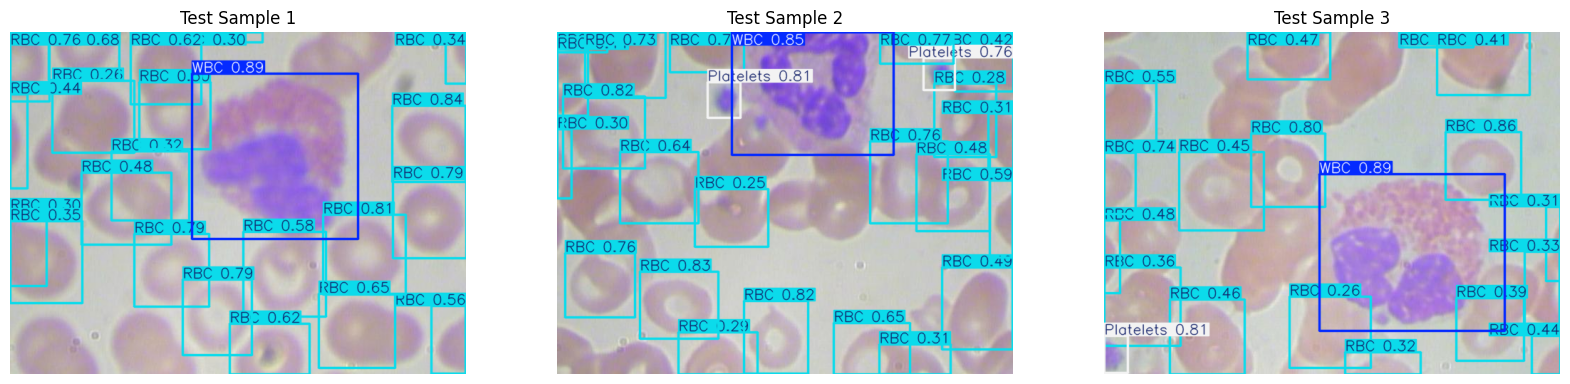

In [15]:
test_images= glob.glob('/content/2022170413/yolo_dataset/images/test/*.jpg')
random_samples= random.sample(test_images,3)
plt.figure(figsize=(20, 10))

for i, img_path in enumerate(random_samples):
    results= model.predict(img_path, conf=0.25)
    result_img= results[0].plot()
    #converting BGR (OpenCV) to RGB (Matplotlib)
    result_img_rgb = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 3, i + 1)
    plt.imshow(result_img_rgb)
    plt.axis('off')
    plt.title(f"Test Sample {i+1}")

plt.show()